## Imports

In [1]:
suppressPackageStartupMessages({
  library(ggplot2)
  library(patchwork)
  library(reshape2)
  library(dplyr)
})

## Prep Data

In [2]:
# data prep
df <- read.csv("../../data/figure-inputs/metadata/patient_gex_cyto_for_heatmap.csv", row.names = 1)

gene_mapping_list <- list(
  "t11;14" = c("CCND1"),
  "t14;16" = c("CCND2"),
  "t14;20" = c("MAFB"),
  "CHR3"   = c("TNFSF10", "RHOA", "EIF4A2"),
  "CHR5"   = c("MAP3K1", "TERT", "CSNK1A1"),
  "CHR7"   = c("CDK6", "EGFR", "RAC1"),
  "CHR9"   = c("NFKBIA", "JAK2", "PTPRD"),
  "CHR11"  = c("PAK1", "ATM", "BIRC3"),
  "CHR15"  = c("B2M", "RAB27A", "AP3B1"),
  "CHR19"  = c("AKT2", "CEBPA", "ICAM1")
)

gene_group_lookup <- stack(gene_mapping_list)
colnames(gene_group_lookup) <- c("Gene", "Group")

# GEX prep
genes_present <- unlist(gene_mapping_list)
gex_data <- df[, genes_present] %>%
  mutate(Patient = rownames(df)) %>%
  reshape2::melt(id.vars = "Patient", variable.name = "Gene", value.name = "Expression") %>%
  left_join(gene_group_lookup, by = "Gene") %>%
  mutate(
    Group = factor(Group, levels = names(gene_mapping_list)),
    Gene = factor(Gene, levels = rev(genes_present)), 
    Patient = factor(Patient, levels = rownames(df))
  )

# cyto prep
cyto_labels <- c("17p Loss", "1q Gain", "1p Loss", "t(11;14)", 
                 "t(14;16)", "t(14;20)", "t(4;14)", "Karyotype")
cyto_columns <- c("cyto.17p_loss", "cyto.1q_gain", "cyto.1p_loss", "cyto.t11_14",
                  "cyto.t14_16", "cyto.t14_20", "cyto.t4_14", "cyto.karyotype")

cyto_data <- df %>%
  select(all_of(cyto_columns)) %>%
  mutate(Patient = rownames(df)) %>%
  reshape2::melt(id.vars = "Patient", variable.name = "Annotation", value.name = "Status") %>%
  mutate(
    Patient = factor(Patient, levels = rownames(df)),
    Annotation = factor(Annotation, levels = rev(cyto_columns), labels = rev(cyto_labels)),
    # Create a helper for the legend
    Point_Type = ifelse(Status == "Abnormal", "Abnormal", NA)
  )
     

## Create plot

In [3]:
# plot 1 - cytogenetics
p_annotation <- ggplot(cyto_data, aes(x = Patient, y = Annotation)) +
  geom_tile(aes(fill = Status), color = "black", linewidth = 0.5) +
  # Map shape to Point_Type to get the legend entry
  geom_point(data = subset(cyto_data, !is.na(Point_Type)), 
             aes(shape = Point_Type), color = "maroon", size = 2, stroke = 1) +
  scale_fill_manual(
    values = c("Yes" = "#4F7942", "Not Tested" = "gray80", "No" = "white", "Normal" = "white", "Abnormal" = "white"),
    breaks = c("Yes", "Not Tested"),
    name = "Cytogenetics"
  ) +
  scale_shape_manual(values = c("Abnormal" = 4), name = "") +
  scale_x_discrete(expand = c(0,0)) + 
  scale_y_discrete(expand = c(0,0)) +
  theme_minimal(base_size=14) +
  theme(
    axis.text.x = element_blank(),
    axis.text.y = element_text(face = 'bold'),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 0.75),
    plot.margin = margin(b = 0, l = 5, r = 55, t = 5)
  )


In [4]:
# plot 2 - heatmap
p_heatmap <- ggplot(gex_data, aes(x = Patient, y = Gene, fill = Expression)) +
  geom_tile(color = "black", linewidth = 0.5) +
  facet_grid(Group ~ ., scales = "free_y", space = "free_y") +
  scale_fill_gradient2(
    low = "navyblue", mid = "white", high = "red4",
    midpoint = 0, limits = c(-2, 2),
    oob = scales::squish
  ) +
  scale_x_discrete(expand = c(0, 0)) +
  scale_y_discrete(expand = c(0, 0)) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.text.y = element_text(face = "bold"),
    strip.text.y = element_text(angle = 0, colour = "black", hjust = 0),
    strip.background = element_blank(),
    panel.spacing = unit(0.35, "lines"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 0.75),
    panel.grid = element_blank(),
    axis.title = element_blank(),
    plot.margin = margin(t = 8, l = 5, r = 5, b = 5)
  )
# guides(fill = "none")

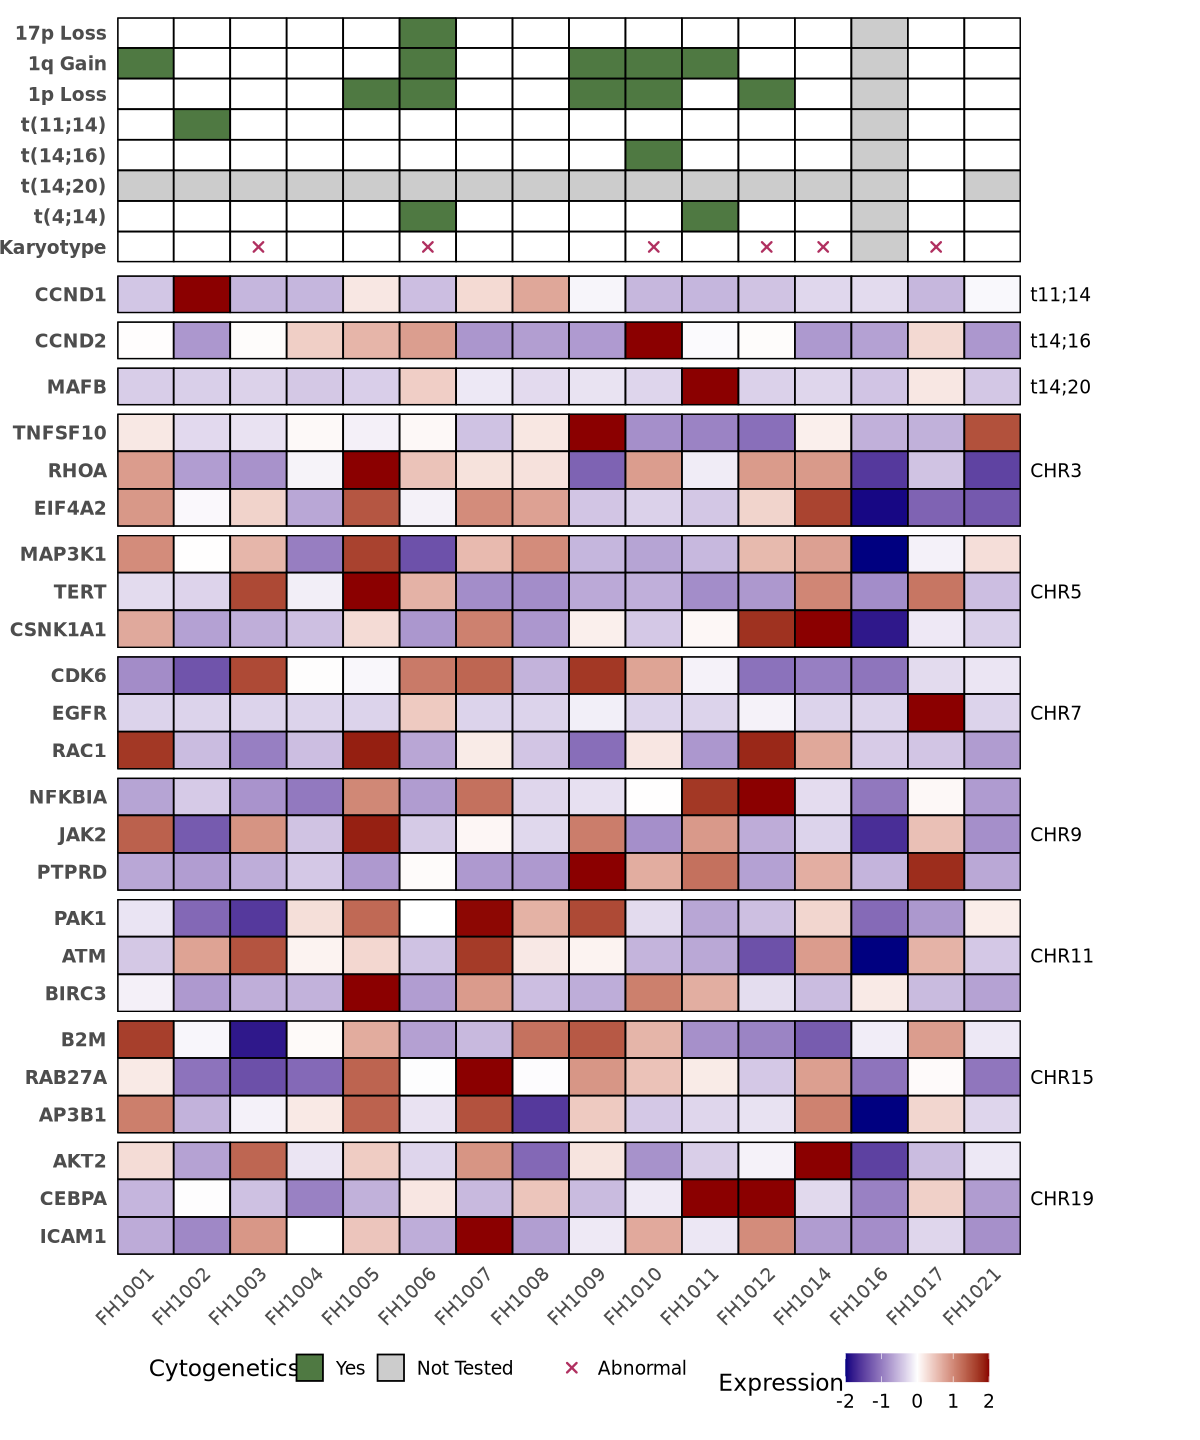

In [5]:
# combine plots
final_plot <- (p_annotation / p_heatmap) + 
  plot_layout(heights = c(1, 4), guides = "collect") & 
  theme(legend.position = "bottom", legend.box = "horizontal")

options(repr.plot.width = 10, repr.plot.height = 12)
final_plot

ggsave("../../data/figure-outputs/supplementary-1/sup_1a.pdf", plot = final_plot, width = 10, height = 12, device = cairo_pdf)